In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

print(os.getcwd())  # Prints the current folder Jupyter is looking inside

C:\Users\ThinkPad


In [3]:
#Reading the data
import os
import pandas as pd

# Point Jupyter to  project folder
os.chdir(r"C:\Users\ThinkPad\OneDrive\Desktop\School\School")

df=pd.read_excel("Dataset for Data Analytics.xlsx")
print(df.head(10))

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   
5  ORD200005 2023-10-23     C37249    Phone         2     245.86   
6  ORD200006 2025-06-17     C83492   Laptop         1     664.42   
7  ORD200007 2023-05-12     C41460  Monitor         5     149.55   
8  ORD200008 2025-04-02     C26817    Phone         2     134.28   
9  ORD200009 2023-11-21     C31946     Desk         4     509.38   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit

In [4]:
#Cleaning
df.shape

(1200, 14)

In [5]:
#Finding missing values
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
#Filling Coupon code row with the mode
df['CouponCode'] = df['CouponCode'].fillna(df['CouponCode'].mode()[0])
print(df)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card     Shipped    TRK37947903        

In [7]:
#Total Sales per product
product_totals= (df.groupby('Product')['TotalPrice']
                 .sum(numeric_only=True)
                 .reset_index()
                 .sort_values(by="TotalPrice", ascending =False)
                             )

print(product_totals)
    


   Product  TotalPrice
0    Chair   195620.11
5  Printer   195612.61
2   Laptop   192126.56
6   Tablet   186568.95
3  Monitor   175651.41
1     Desk   167459.93
4    Phone   151722.39


In [8]:
#Analysis
total_sales=df['TotalPrice'].sum()
print(f'\nTotal Sales : {total_sales:.2f}')


Total Sales : 1264761.96


In [9]:
# Aggregating total sales per customer
customer_spend=( df.groupby("CustomerID").agg(TotalSpend=("TotalPrice", "sum"), OrderCount=("OrderID","count")).reset_index())

#Top 10 customers
top_10 = customer_spend.sort_values(by="TotalSpend", ascending=False).head(10)
print("~Top 10 Customers~")
print(top_10)

#Bottom 10 customers
bottom_10 = customer_spend.sort_values(by="TotalSpend",ascending=True).head(10)
print("\n~Bottom 10 Customers~")
print(bottom_10)

~Top 10 Customers~
    CustomerID  TotalSpend  OrderCount
403     C38840     5723.23           2
648     C57276     3456.40           1
781     C67260     3390.80           1
56      C13877     3384.90           1
123     C18404     3370.20           1
97      C16775     3353.75           1
764     C65986     3352.40           1
520     C47778     3334.00           1
669     C59183     3322.55           1
211     C25276     3313.90           1

~Bottom 10 Customers~
     CustomerID  TotalSpend  OrderCount
316      C32570       11.39           1
1163     C98276       14.06           1
76       C14983       17.24           1
550      C49726       17.98           1
1031     C88174       18.20           1
806      C69168       21.19           1
254      C28406       23.53           1
269      C29318       24.48           1
784      C67533       26.95           1
255      C28552       29.86           1


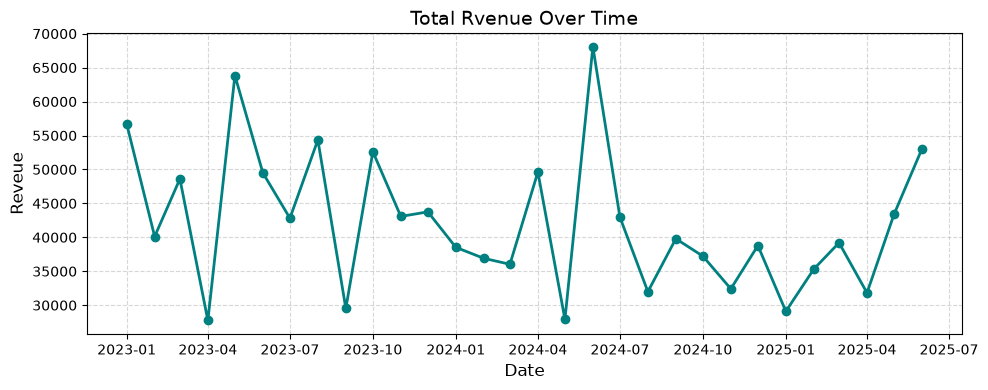

In [10]:
#Visualisation
#Converting date to extract monthly period
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")

overall_monthly =df.groupby("Month")['TotalPrice'].sum()
overall_monthly.index=overall_monthly.index.to_timestamp() 

plt.figure(figsize=(10,4))
plt.plot(overall_monthly.index, overall_monthly.values,color="teal", linewidth=2, marker="o")
plt.title("Total Rvenue Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Reveue", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

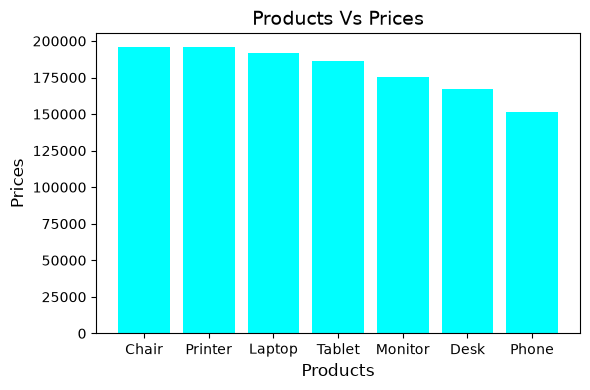

In [11]:
plt.figure(figsize=(6,4))
plt.bar(product_totals["Product"], product_totals["TotalPrice"], color="cyan")
plt.title("Products Vs Prices", fontsize=14)
plt.xlabel("Products", fontsize=12)
plt.ylabel("Prices", fontsize=12)
plt.tight_layout()
plt.show()